In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import os

In [8]:
BASE_PATH = "/Users/quantumapple/Desktop/Masters/DATASCI507/stats507win2026/"  
FRAME_ID  = "000010"

def load_image(frame_id):
    path = os.path.join(BASE_PATH,"data_object_image_2/training/","image_2", f"{frame_id}.png")
    img  = plt.imread(path)              # returns H×W×3 float array (0–1 range)
    return img

def show_image(img, title="KITTI Camera Frame"):
    plt.figure(figsize=(14, 5))
    plt.imshow(img)
    plt.title(title, fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Image shape: {img.shape}  →  Height={img.shape[0]}px, Width={img.shape[1]}px, Channels={img.shape[2]}")

In [13]:
def load_lidar(frame_id):
    path   = os.path.join(BASE_PATH, "data_object_velodyne/training/","velodyne", f"{frame_id}.bin")
    # Each point is stored as 4 x float32 values: X, Y, Z, Intensity
    points = np.fromfile(path, dtype=np.float32)
    points = points.reshape(-1, 4)       # reshape into (N, 4) matrix
    return points

def show_lidar_info(points):
    print("=" * 50)
    print("LiDAR Point Cloud Info")
    print("=" * 50)
    print(f"Shape      : {points.shape}  →  {points.shape[0]} points, {points.shape[1]} values per point")
    print(f"Columns    : [X, Y, Z, Intensity]")
    print(f"X range    : {points[:, 0].min():.2f}m  to  {points[:, 0].max():.2f}m  (forward/back)")
    print(f"Y range    : {points[:, 1].min():.2f}m  to  {points[:, 1].max():.2f}m  (left/right)")
    print(f"Z range    : {points[:, 2].min():.2f}m  to  {points[:, 2].max():.2f}m  (up/down)")
    print(f"Intensity  : {points[:, 3].min():.2f}  to  {points[:, 3].max():.2f}")
 
def show_lidar_topdown(points, max_range=40.0):
    """Bird's-eye-view (top-down) scatter plot of the point cloud."""
    # Only keep points in front of the car (X > 0) within max_range
    mask   = (points[:, 0] > 0) & (points[:, 0] < max_range)
    pts    = points[mask]
 
    plt.figure(figsize=(10, 10))
    plt.scatter(pts[:, 0], pts[:, 1],
                c=pts[:, 2],            # color by height (Z)
                cmap="plasma",
                s=0.3,                  # tiny dot per point
                alpha=0.6)
    plt.colorbar(label="Height (Z) in metres")
    plt.xlabel("X — Forward (metres)")
    plt.ylabel("Y — Left/Right (metres)")
    plt.title("LiDAR Point Cloud — Top-Down (Bird's Eye) View")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

In [17]:
# KITTI label columns (one object per row):
LABEL_COLS = [
    "type",           # object class: Car, Pedestrian, Cyclist, DontCare ...
    "truncated",      # 0 (not truncated) to 1 (fully truncated at image border)
    "occluded",       # 0=fully visible, 1=partly, 2=largely, 3=unknown
    "alpha",          # observation angle of object [-pi, pi]
    "left",           # 2D bounding box in image — left pixel
    "top",            # 2D bounding box — top pixel
    "right",          # 2D bounding box — right pixel
    "bottom",         # 2D bounding box — bottom pixel
    "height_3d",      # 3D object height in metres
    "width_3d",       # 3D object width in metres
    "length_3d",      # 3D object length in metres
    "x_3d",           # 3D location X in camera coordinates (metres)
    "y_3d",           # 3D location Y in camera coordinates (metres)
    "z_3d",           # 3D location Z in camera coordinates (metres, = depth!)
    "rotation_y",     # rotation around Y-axis in camera coords [-pi, pi]
]
 
def load_labels(frame_id):
    path = os.path.join(BASE_PATH, "training","label_2", f"{frame_id}.txt")
    rows = []
    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split(" ")
            rows.append([parts[0]] + [float(v) for v in parts[1:]])
    return pd.DataFrame(rows, columns=LABEL_COLS)
 
def show_labels(df):
    print("=" * 50)
    print("Labels for this frame")
    print("=" * 50)
    print(df[["type", "occluded", "z_3d", "height_3d", "width_3d", "length_3d"]].to_string(index=False))
    print(f"\nObject counts:\n{df['type'].value_counts().to_string()}")
 
def show_image_with_boxes(img, df):
    """Draw 2D bounding boxes from labels onto the camera image."""
    fig, ax = plt.subplots(1, figsize=(14, 5))
    ax.imshow(img)
 
    color_map = {"Car": "red", "Pedestrian": "cyan", "Cyclist": "yellow", "DontCare": "gray"}
 
    for _, row in df.iterrows():
        if row["type"] == "DontCare":
            continue
        x1, y1 = row["left"],  row["top"]
        x2, y2 = row["right"], row["bottom"]
        color   = color_map.get(row["type"], "white")
        rect    = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, f"{row['type']} {row['z_3d']:.1f}m",
                color=color, fontsize=8, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.4, pad=1))
 
    ax.set_title("Camera Image with Ground Truth 2D Bounding Boxes")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

In [18]:
def load_calib(frame_id):
    path  = os.path.join(BASE_PATH, "data_object_calib/training/", "calib", f"{frame_id}.txt")
    calib = {}
    with open(path, "r") as f:
        for line in f:
            if ":" not in line:
                continue
            key, vals = line.strip().split(":", 1)
            calib[key.strip()] = np.array([float(v) for v in vals.strip().split()])
    return calib
 
def show_calib(calib):
    print("=" * 50)
    print("Calibration Matrices")
    print("=" * 50)
    shapes = {"P0": (3,4), "P1": (3,4), "P2": (3,4), "P3": (3,4), "R0_rect": (3,3), "Tr_velo_to_cam": (3,4)}
    for key, shape in shapes.items():
        if key in calib:
            mat = calib[key].reshape(shape)
            print(f"\n{key}  {shape}:")
            print(mat)
 
    print("\n--- What each matrix means ---")
    print("P2            : Projects 3D camera coords → 2D image pixel (left color camera)")
    print("R0_rect       : Rectification rotation — aligns stereo cameras to same plane")
    print("Tr_velo_to_cam: Transforms LiDAR (Velodyne) coords → Camera coords  ← KEY for fusion")

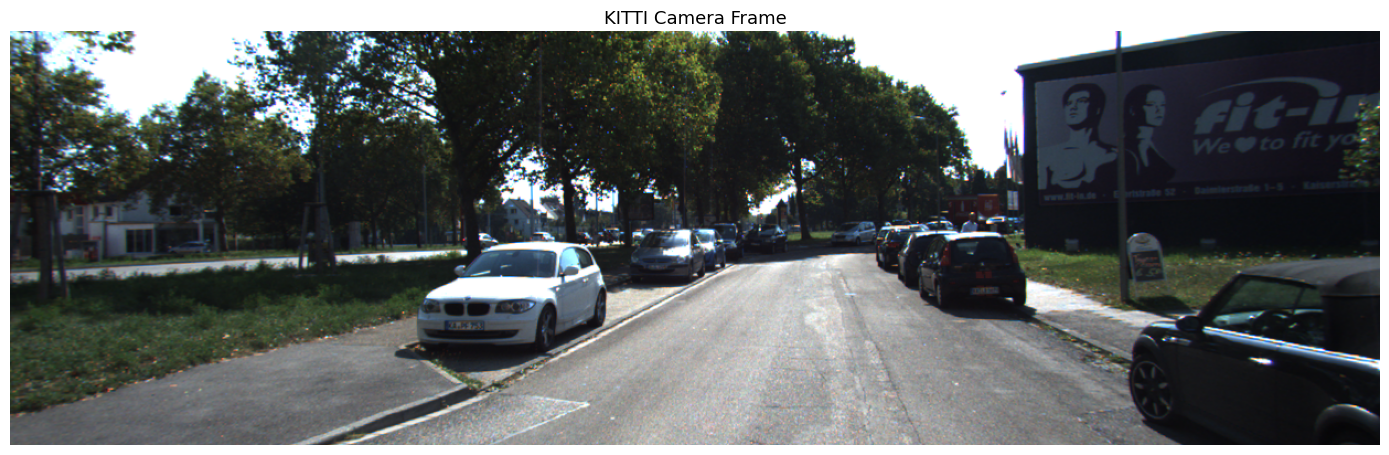

Image shape: (375, 1242, 3)  →  Height=375px, Width=1242px, Channels=3
LiDAR Point Cloud Info
Shape      : (115875, 4)  →  115875 points, 4 values per point
Columns    : [X, Y, Z, Intensity]
X range    : -60.41m  to  78.36m  (forward/back)
Y range    : -68.25m  to  61.63m  (left/right)
Z range    : -14.14m  to  2.91m  (up/down)
Intensity  : 0.00  to  0.99


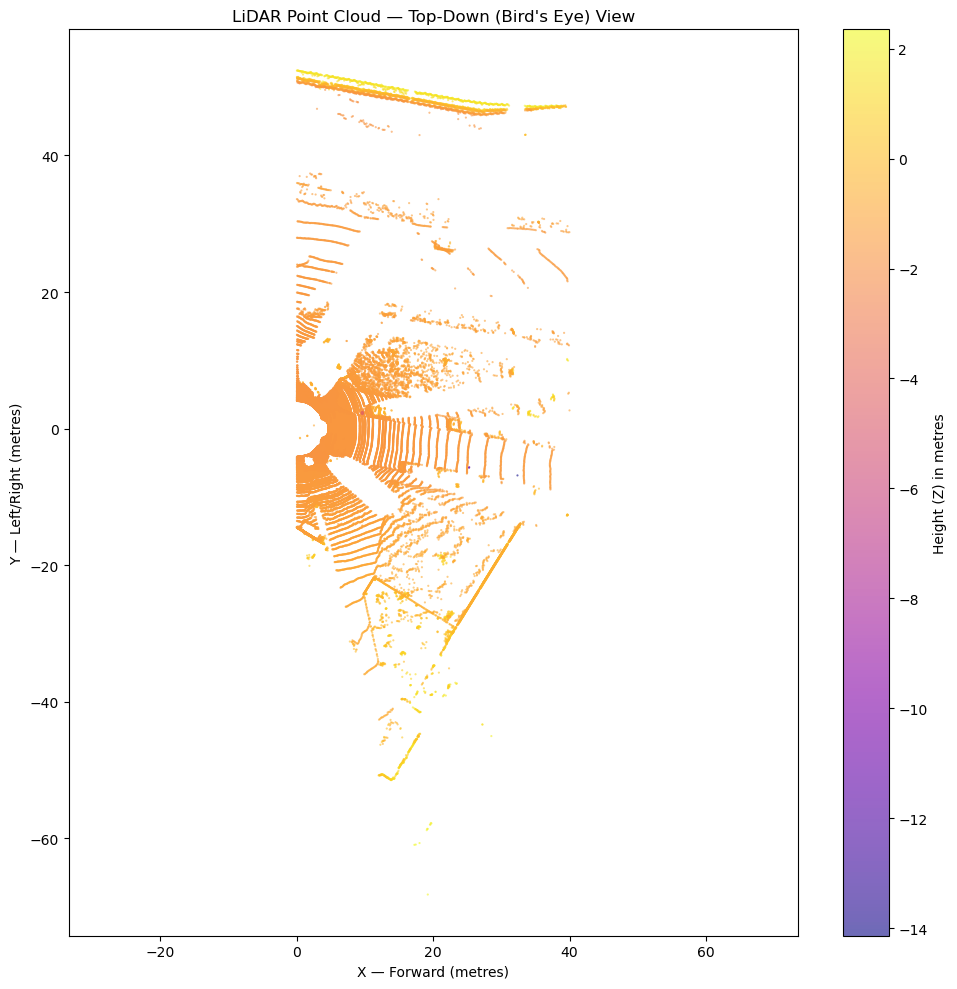

Labels for this frame
      type  occluded     z_3d  height_3d  width_3d  length_3d
       Car       0.0     5.20       1.57      1.65       3.35
       Car       0.0    11.80       1.43      1.70       3.95
Pedestrian       2.0    23.51       1.96      0.72       1.09
       Car       0.0    16.50       1.51      1.60       3.24
       Car       2.0    22.05       1.45      1.74       4.10
       Car       0.0    23.64       1.54      1.68       3.79
       Car       2.0    29.07       1.49      1.52       3.35
       Car       1.0    28.53       1.53      1.65       4.37
       Car       1.0    42.85       1.64      1.45       3.48
  DontCare      -1.0 -1000.00      -1.00     -1.00      -1.00
  DontCare      -1.0 -1000.00      -1.00     -1.00      -1.00
  DontCare      -1.0 -1000.00      -1.00     -1.00      -1.00
  DontCare      -1.0 -1000.00      -1.00     -1.00      -1.00

Object counts:
type
Car           8
DontCare      4
Pedestrian    1


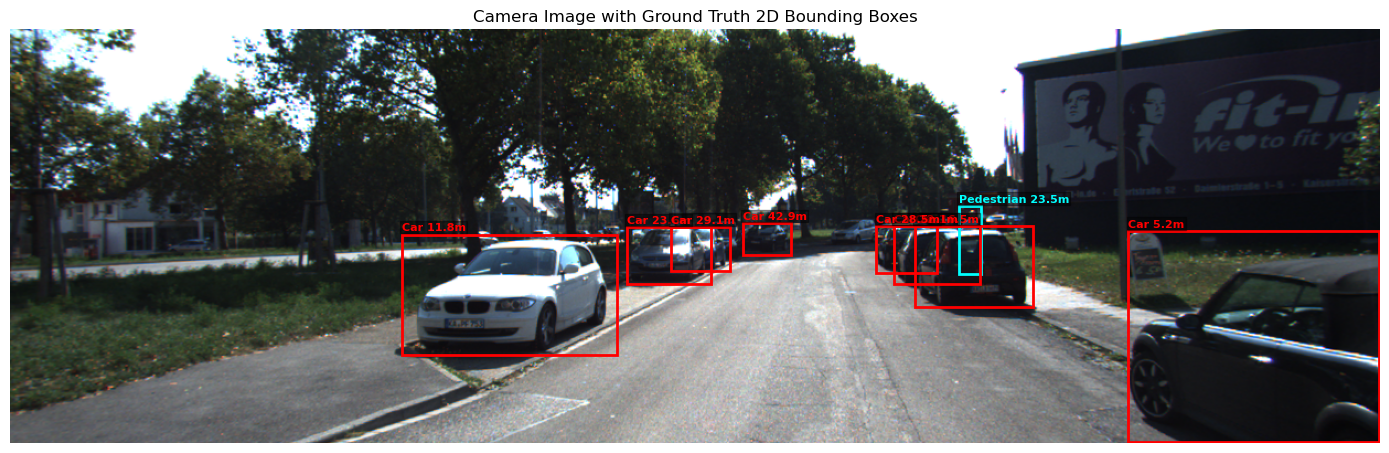

Calibration Matrices

P0  (3, 4):
[[721.5377   0.     609.5593   0.    ]
 [  0.     721.5377 172.854    0.    ]
 [  0.       0.       1.       0.    ]]

P1  (3, 4):
[[ 721.5377    0.      609.5593 -387.5744]
 [   0.      721.5377  172.854     0.    ]
 [   0.        0.        1.        0.    ]]

P2  (3, 4):
[[7.215377e+02 0.000000e+00 6.095593e+02 4.485728e+01]
 [0.000000e+00 7.215377e+02 1.728540e+02 2.163791e-01]
 [0.000000e+00 0.000000e+00 1.000000e+00 2.745884e-03]]

P3  (3, 4):
[[ 7.215377e+02  0.000000e+00  6.095593e+02 -3.395242e+02]
 [ 0.000000e+00  7.215377e+02  1.728540e+02  2.199936e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  2.729905e-03]]

R0_rect  (3, 3):
[[ 0.9999239   0.00983776 -0.00744505]
 [-0.0098698   0.9999421  -0.00427846]
 [ 0.00740253  0.00435161  0.9999631 ]]

Tr_velo_to_cam  (3, 4):
[[ 7.533745e-03 -9.999714e-01 -6.166020e-04 -4.069766e-03]
 [ 1.480249e-02  7.280733e-04 -9.998902e-01 -7.631618e-02]
 [ 9.998621e-01  7.523790e-03  1.480755e-02 -2.717806e-0

In [19]:
 # Step 1 — Image
img = load_image(FRAME_ID)
show_image(img)

# Step 2 — LiDAR
points = load_lidar(FRAME_ID)
show_lidar_info(points)
show_lidar_topdown(points)
 
# Step 3 — Labels
df = load_labels(FRAME_ID)
show_labels(df)
show_image_with_boxes(img, df)
 
# Step 4 — Calibration
calib = load_calib(FRAME_ID)
show_calib(calib)